In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
import lightgbm as lgb
import optuna
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import KFold
from sklearn.metrics import cohen_kappa_score
import warnings
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import warnings
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import catboost as cb
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
import torch

# Load the dataset
df = pd.read_csv('../Dataset/cmi_internet.csv')

# Handle Target Leakage (PCIAT, Season, AND CGAS_Score proxy leakage)
pciat_cols_to_drop = [col for col in df.columns if 'PCIAT' in col and col != 'PCIAT-PCIAT_Total']
season_cols_to_drop = [col for col in df.columns if 'Season' in col]

# We DO NOT drop 'sii' here, so we can use it to find the test set
additional_leaks = ['CGAS-CGAS_Score'] 

cols_to_drop = pciat_cols_to_drop + season_cols_to_drop + [c for c in additional_leaks if c in df.columns]
df = df.drop(columns=cols_to_drop, errors='ignore')

# Keep only numeric data
numeric_df = df.select_dtypes(include=[np.number])

# --- SPLIT LOGIC ---
# Train Set: Rows that HAVE PCIAT-PCIAT_Total
train_df = numeric_df.dropna(subset=['PCIAT-PCIAT_Total']).copy()

# Test Set: Rows that DO NOT have PCIAT-PCIAT_Total, but DO have 'sii'
test_df = numeric_df[
    (numeric_df['PCIAT-PCIAT_Total'].isna()) & 
    (numeric_df['sii'].notna())
].copy()

print(f"Initial split found {len(train_df)} Train elements (Has PCIAT).")
print(f"Initial split found {len(test_df)} Test elements (No PCIAT, but has SII).")

if len(test_df) == 0:
    print("\nWARNING: There are exactly 0 rows that are missing PCIAT but have an 'sii' label.")
    print("WARNING: Reverting to a manual 80/20 train_test_split on the valid data.")
    from sklearn.model_selection import train_test_split
    X = train_df.drop(columns=['PCIAT-PCIAT_Total', 'id', 'sii'], errors='ignore')
    y = train_df['PCIAT-PCIAT_Total']
    y_sii_fallback = train_df['sii']
    
    X_train_cv, X_test, y_train_cv, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    _, _, _, y_test_sii_true = train_test_split(X, y_sii_fallback, test_size=0.2, random_state=42)
    
else:
    print("\nSUCCESS: Custom split works! Proceeding with isolated Test Set.")
    X_train_cv = train_df.drop(columns=['PCIAT-PCIAT_Total', 'id', 'sii'], errors='ignore')
    y_train_cv = train_df['PCIAT-PCIAT_Total']
    X_test = test_df.drop(columns=['PCIAT-PCIAT_Total', 'id', 'sii'], errors='ignore')
    y_test = None
    y_test_sii_true = test_df['sii']

# Reset ALL indices safely
X_train_cv = X_train_cv.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train_cv = y_train_cv.reset_index(drop=True)

if y_test is not None:
    y_test = y_test.reset_index(drop=True)
    
y_test_sii_true = y_test_sii_true.reset_index(drop=True)

print(f"\nX_train_cv shape: {X_train_cv.shape}")
print(f"X_test shape: {X_test.shape}")

Initial split found 2736 Train elements (Has PCIAT).
Initial split found 0 Test elements (No PCIAT, but has SII).


X_train_cv shape: (2188, 47)
X_test shape: (548, 47)


/Users/alessandro/miniforge3/envs/m4_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================================
# Cell 1 (was Cell 1 + Cell 2): Shared preprocessing utilities
# 
# FIX: Outlier detection is NO LONGER done globally here.
# It will be done inside each CV fold to prevent leakage.
# The old Cell 2 (global scaler + imputer) is also removed.
# Everything is now handled per-fold in the Optuna objectives
# and in the final training cell.
# ============================================================================



warnings.filterwarnings('ignore')

def detect_consensus_outliers(X_array):
    """
    Consensus outlier detection on already-imputed numeric array.
    Returns boolean mask (True = outlier).
    """
    # 1. Isolation Forest
    iso_forest = IsolationForest(random_state=42, n_estimators=100)
    outliers_iso = iso_forest.fit_predict(X_array) == -1

    # 2. LOF
    lof = LocalOutlierFactor(n_neighbors=20)
    outliers_lof = lof.fit_predict(X_array) == -1

    # 3. PCA-Reconstruction
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_array)
    X_reconstructed = pca.inverse_transform(X_pca)
    reconstruction_error = np.mean((X_array - X_reconstructed) ** 2, axis=1)
    threshold_pca = np.percentile(reconstruction_error, 95)
    outliers_pca = reconstruction_error > threshold_pca

    # 4. One-Class SVM
    ocsvm = OneClassSVM(nu=0.05)
    outliers_ocsvm = ocsvm.fit_predict(X_array) == -1

    # 5. ABOD
    try:
        from pyod.models.abod import ABOD
        abod = ABOD()
        abod.fit(X_array)
        outliers_abod = abod.labels_ == 1
    except ImportError:
        outliers_abod = np.zeros(X_array.shape[0], dtype=bool)

    outlier_votes = (outliers_iso.astype(int) + outliers_lof.astype(int) + 
                     outliers_pca.astype(int) + outliers_ocsvm.astype(int) + 
                     outliers_abod.astype(int))
    return outlier_votes > 2


def preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True):
    """
    Full preprocessing pipeline for a single CV fold.
    Fit on train only, transform val. Optionally remove outliers from train.
    Returns: X_tr, X_val, y_tr (potentially filtered)
    """
    # 1. Scale
    fold_scaler = StandardScaler()
    X_tr_sc = fold_scaler.fit_transform(X_tr_raw)
    X_val_sc = fold_scaler.transform(X_val_raw)
    
    # 2. Impute (temp median for outlier detection)
    if remove_outliers:
        temp_imp = SimpleImputer(strategy='median')
        X_tr_temp = temp_imp.fit_transform(X_tr_sc)
        
        # 3. Outlier detection on train fold only
        outlier_mask = detect_consensus_outliers(X_tr_temp)
        X_tr_sc = X_tr_sc[~outlier_mask]
        y_tr = y_tr[~outlier_mask].reset_index(drop=True)
    
    # 4. Iterative Imputation (same pipeline as final training)
    fold_imputer = IterativeImputer(
        estimator=Lasso(alpha=0.1, random_state=42), 
        max_iter=10, random_state=42
    )
    X_tr = fold_imputer.fit_transform(X_tr_sc)
    X_val = fold_imputer.transform(X_val_sc)
    
    return X_tr, X_val, y_tr, fold_scaler, fold_imputer


warnings.filterwarnings('ignore', category=UserWarning)

os.makedirs('../results', exist_ok=True)

class SaveCallback:
    """Callback to save trials to CSV after every single trial, accumulating with history."""
    def __init__(self, res_path):
        self.res_path = res_path
        self.old_trials = None
        if os.path.exists(res_path):
            self.old_trials = pd.read_csv(res_path)

    def __call__(self, study, trial):
        df_current = study.trials_dataframe()
        if self.old_trials is not None:
            # Accumulate historical trials with ALL trials from the current session
            df_total = pd.concat([self.old_trials, df_current], ignore_index=True)
        else:
            df_total = df_current
        df_total.to_csv(self.res_path, index=False)

def get_sii(scores):
    scores = np.clip(np.round(scores), 0, 100)
    sii = np.zeros_like(scores, dtype=int)
    sii[(scores >= 31) & (scores <= 49)] = 1
    sii[(scores >= 50) & (scores <= 79)] = 2
    sii[scores >= 80] = 3
    return sii

print("Preprocessing utilities and SaveCallback defined.")

Preprocessing utilities and SaveCallback defined.


In [3]:

def objective_lgbm(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    qwk_scores = []
    
    for train_idx, valid_idx in cv.split(X_train_cv):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]
        
        # FULL PIPELINE PER FOLD: scale, outlier removal, impute
        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        preds = np.nan_to_num(preds, nan=np.nanmedian(y_tr))
        
        preds_sii = get_sii(preds)
        y_val_sii = get_sii(y_val)
        
        qwk = cohen_kappa_score(y_val_sii, preds_sii, weights='quadratic')
        qwk_scores.append(qwk)
        
    return np.mean(qwk_scores)

print("Starting LightGBM optimization...")
res_path = '../results/lgbm_trials.csv'
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lgbm = optuna.create_study(direction='maximize', study_name='LightGBM')
study_lgbm.optimize(
    objective_lgbm, 
    n_trials=50, 
    show_progress_bar=True, 
    n_jobs=4,
    callbacks=[SaveCallback(res_path)]
)

print(f"\nOptimization cycle complete for LightGBM.")
if os.path.exists(res_path):
    df_total = pd.read_csv(res_path)
    print(f"Total trials recorded in history: {len(df_total)}")
    print(f"Best trial average CV QWK so far: {df_total['value'].max():.4f}")
    print(f"Trials saved incrementally to {res_path}")

Starting LightGBM optimization...


Best trial: 26. Best value: 0.398572: 100%|██████████| 50/50 [06:17<00:00,  7.55s/it]


Total trials recorded for LightGBM: 100
Best trial average CV QWK so far:
  Value (QWK): 0.3986
  Saved trials to ../results/lgbm_trials.csv


In [4]:

def objective_xgb(trial):
    params = {
        'objective': 'reg:squarederror',
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbosity': 0
    }
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    qwk_scores = []
    
    for train_idx, valid_idx in cv.split(X_train_cv):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]
        
        # FULL PIPELINE PER FOLD
        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        preds = np.nan_to_num(preds, nan=np.nanmedian(y_tr))
        
        preds_sii = get_sii(preds)
        y_val_sii = get_sii(y_val)
        
        qwk = cohen_kappa_score(y_val_sii, preds_sii, weights='quadratic')
        qwk_scores.append(qwk)
        
    return np.mean(qwk_scores)

print("Starting XGBoost optimization...")
res_path = '../results/xgb_trials.csv'
study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost')
study_xgb.optimize(
    objective_xgb, 
    n_trials=50, 
    show_progress_bar=True, 
    n_jobs=4,
    callbacks=[SaveCallback(res_path)]
)

print(f"\nOptimization cycle complete for XGBoost.")
if os.path.exists(res_path):
    df_total = pd.read_csv(res_path)
    print(f"Total trials recorded in history: {len(df_total)}")
    print(f"Best trial average CV QWK so far: {df_total['value'].max():.4f}")
    print(f"Trials saved incrementally to {res_path}")

Starting XGBoost optimization...


Best trial: 45. Best value: 0.399386: 100%|██████████| 50/50 [03:58<00:00,  4.78s/it]


Total trials recorded for XGBoost: 100
Best trial average CV QWK so far:
  Value (QWK): 0.4022
  Saved trials to ../results/xgb_trials.csv


In [5]:

def objective_cb(trial):
    params = {
        'loss_function': 'RMSE',
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'iterations': trial.suggest_int('iterations', 50, 300),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_seed': 42,
        'verbose': False,
        'allow_writing_files': False
    }
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    qwk_scores = []
    
    for train_idx, valid_idx in cv.split(X_train_cv):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]
        
        # FULL PIPELINE PER FOLD
        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
        
        model = cb.CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, verbose=False)
        
        preds = model.predict(X_val)
        preds = np.nan_to_num(preds, nan=np.nanmedian(y_tr))
        
        preds_sii = get_sii(preds)
        y_val_sii = get_sii(y_val)
        
        qwk = cohen_kappa_score(y_val_sii, preds_sii, weights='quadratic')
        qwk_scores.append(qwk)
        
    return np.mean(qwk_scores)

print("Starting CatBoost optimization...")
res_path = '../results/cb_trials.csv'
study_cb = optuna.create_study(direction='maximize', study_name='CatBoost')
study_cb.optimize(
    objective_cb, 
    n_trials=50, 
    show_progress_bar=True, 
    n_jobs=1,
    callbacks=[SaveCallback(res_path)]
)

print(f"\nOptimization cycle complete for CatBoost.")
if os.path.exists(res_path):
    df_total = pd.read_csv(res_path)
    print(f"Total trials recorded in history: {len(df_total)}")
    print(f"Best trial average CV QWK so far: {df_total['value'].max():.4f}")
    print(f"Trials saved incrementally to {res_path}")

Starting CatBoost optimization...


Best trial: 31. Best value: 0.400725: 100%|██████████| 50/50 [08:21<00:00, 10.04s/it]


Total trials recorded for CatBoost: 100
Best trial average CV QWK so far:
  Value (QWK): 0.4071
  Saved trials to ../results/cb_trials.csv


In [ ]:

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    qwk_scores = []
    
    for train_idx, valid_idx in cv.split(X_train_cv):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]
        
        # FULL PIPELINE PER FOLD
        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
        
        model = RandomForestRegressor(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        preds = np.nan_to_num(preds, nan=np.nanmedian(y_tr))
        
        preds_sii = get_sii(preds)
        y_val_sii = get_sii(y_val)
        
        qwk = cohen_kappa_score(y_val_sii, preds_sii, weights='quadratic')
        qwk_scores.append(qwk)
        
    return np.mean(qwk_scores)

print("Starting RandomForest optimization...")
res_path = '../results/rf_trials.csv'
study_rf = optuna.create_study(direction='maximize', study_name='RandomForest')
study_rf.optimize(
    objective_rf, 
    n_trials=50, 
    show_progress_bar=True, 
    n_jobs=1,
    callbacks=[SaveCallback(res_path)]
)

print(f"\nOptimization cycle complete for RandomForest.")
if os.path.exists(res_path):
    df_total = pd.read_csv(res_path)
    print(f"Total trials recorded in history: {len(df_total)}")
    print(f"Best trial average CV QWK so far: {df_total['value'].max():.4f}")
    print(f"Trials saved incrementally to {res_path}")

Starting RandomForest optimization...


Best trial: 48. Best value: 0.393005: 100%|██████████| 50/50 [06:21<00:00,  7.62s/it]


Total trials recorded for RandomForest: 100
Best trial average CV QWK so far:
  Value (QWK): 0.3930
  Saved trials to ../results/rf_trials.csv


: 

In [3]:

def objective_ridge(trial):
    params = {
        'alpha': trial.suggest_float('alpha', 0.01, 100.0, log=True),
        'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
        'random_state': 42
    }
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    qwk_scores = []
    
    for train_idx, valid_idx in cv.split(X_train_cv):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]
        
        # FULL PIPELINE PER FOLD
        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
        
        model = Ridge(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        preds = np.nan_to_num(preds, nan=np.nanmedian(y_tr))
        
        preds_sii = get_sii(preds)
        y_val_sii = get_sii(y_val)
        
        qwk = cohen_kappa_score(y_val_sii, preds_sii, weights='quadratic')
        qwk_scores.append(qwk)
        
    return np.mean(qwk_scores)

print("Starting Multivariate Linear Regression (Ridge) optimization...")
res_path = '../results/linreg_trials.csv'
study_ridge = optuna.create_study(direction='maximize', study_name='Ridge')
study_ridge.optimize(
    objective_ridge, 
    n_trials=50, 
    show_progress_bar=True, 
    n_jobs=4,
    callbacks=[SaveCallback(res_path)]
)

print(f"\nOptimization cycle complete for Ridge.")
if os.path.exists(res_path):
    df_total = pd.read_csv(res_path)
    print(f"Total trials recorded in history: {len(df_total)}")
    print(f"Best trial average CV QWK so far: {df_total['value'].max():.4f}")
    print(f"Trials saved incrementally to {res_path}")

[I 2026-04-09 10:08:11,403] A new study created in memory with name: Ridge


Starting Multivariate Linear Regression (Ridge) optimization...


Best trial: 0. Best value: 0.362476:   2%|▏         | 1/50 [00:15<12:21, 15.14s/it]

[I 2026-04-09 10:08:26,550] Trial 0 finished with value: 0.36247633216489816 and parameters: {'alpha': 7.285959511423555, 'solver': 'lsqr'}. Best is trial 0 with value: 0.36247633216489816.


Best trial: 0. Best value: 0.362476:   4%|▍         | 2/50 [00:15<05:09,  6.46s/it]

...

[I 2026-04-09 10:11:20,416] Trial 47 finished with value: 0.363309143721853 and parameters: {'alpha': 0.4469988431429514, 'solver': 'sag'}. Best is trial 34 with value: 0.37837347686609146.


Best trial: 34. Best value: 0.378373:  98%|█████████▊| 49/50 [03:13<00:03,  3.71s/it]

[I 2026-04-09 10:11:25,313] Trial 48 finished with value: 0.3620466992393913 and parameters: {'alpha': 0.30728500169517586, 'solver': 'sag'}. Best is trial 34 with value: 0.37837347686609146.


Best trial: 34. Best value: 0.378373: 100%|██████████| 50/50 [03:15<00:00,  3.90s/it]

[I 2026-04-09 10:11:26,427] Trial 49 finished with value: 0.36319459360231143 and parameters: {'alpha': 0.6272443944353272, 'solver': 'sag'}. Best is trial 34 with value: 0.37837347686609146.

Optimization cycle complete for Ridge.
Total trials recorded in history: 131
Best trial average CV QWK so far: 0.3784
Trials saved incrementally to ../results/linreg_trials.csv


In [3]:

def objective_svr(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 100.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 1.0, log=True),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid']),
        'degree': trial.suggest_int('degree', 2, 5) if trial.params.get('kernel') == 'poly' else 3,
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
    }
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    qwk_scores = []
    
    for train_idx, valid_idx in cv.split(X_train_cv):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]
        
        # FULL PIPELINE PER FOLD
        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
        
        model = SVR(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        preds = np.nan_to_num(preds, nan=np.nanmedian(y_tr))
        
        preds_sii = get_sii(preds)
        y_val_sii = get_sii(y_val)
        
        qwk = cohen_kappa_score(y_val_sii, preds_sii, weights='quadratic')
        qwk_scores.append(qwk)
        
    return np.mean(qwk_scores)

print("Starting SVR optimization...")
res_path = '../results/svr_trials.csv'
study_svr = optuna.create_study(direction='maximize', study_name='SVR')
study_svr.optimize(
    objective_svr, 
    n_trials=50, 
    show_progress_bar=True, 
    callbacks=[SaveCallback(res_path)]
)

print(f"\nOptimization cycle complete for SVR.")
if os.path.exists(res_path):
    df_total = pd.read_csv(res_path)
    print(f"Total trials recorded in history: {len(df_total)}")
    print(f"Best trial average CV QWK so far: {df_total['value'].max():.4f}")
    print(f"Trials saved incrementally to {res_path}")

[I 2026-04-09 10:15:46,145] A new study created in memory with name: SVR


Starting SVR optimization...


Best trial: 0. Best value: 0.366699:   2%|▏         | 1/50 [00:11<09:09, 11.21s/it]

[I 2026-04-09 10:15:57,366] Trial 0 finished with value: 0.366698697719752 and parameters: {'C': 37.33894597422344, 'epsilon': 0.5136892966443659, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 0 with value: 0.366698697719752.


Best trial: 0. Best value: 0.366699:   4%|▍         | 2/50 [00:17<06:45,  8.46s/it]

...

[I 2026-04-09 10:29:20,691] Trial 47 finished with value: 0.36468115612062907 and parameters: {'C': 0.2644048885881088, 'epsilon': 0.4209849705693153, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 32 with value: 0.3691938148090178.


Best trial: 32. Best value: 0.369194:  98%|█████████▊| 49/50 [13:40<00:09,  9.01s/it]

[I 2026-04-09 10:29:26,892] Trial 48 finished with value: 0.36623284397223077 and parameters: {'C': 0.39216317994212246, 'epsilon': 0.27178562353898517, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 32 with value: 0.3691938148090178.


Best trial: 32. Best value: 0.369194: 100%|██████████| 50/50 [13:46<00:00, 16.54s/it]

[I 2026-04-09 10:29:33,100] Trial 49 finished with value: 0.13653701866238016 and parameters: {'C': 0.1489453000949002, 'epsilon': 0.08961794647005049, 'kernel': 'poly', 'degree': 3, 'gamma': 'scale'}. Best is trial 32 with value: 0.3691938148090178.

Optimization cycle complete for SVR.
Total trials recorded in history: 118
Best trial average CV QWK so far: 0.3740
Trials saved incrementally to ../results/svr_trials.csv


In [ ]:
def objective_nn(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(256, 128, 64), (128, 64, 32)]),
        'activation': trial.suggest_categorical('activation', [ 'logistic', 'relu', 'tanh']),
        'solver': trial.suggest_categorical('solver', ['adam']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-5, 1e-2, log=True),
        'max_iter': 500,
        'random_state': 42
    }
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    qwk_scores = []
    
    for train_idx, valid_idx in cv.split(X_train_cv):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]
        
        # FULL PIPELINE PER FOLD
        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
        
        model = MLPRegressor(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        preds = np.nan_to_num(preds, nan=np.nanmedian(y_tr))
        
        preds_sii = get_sii(preds)
        y_val_sii = get_sii(y_val)
        
        qwk = cohen_kappa_score(y_val_sii, preds_sii, weights='quadratic')
        qwk_scores.append(qwk)
        
    return np.mean(qwk_scores)

print("Starting MLP Neural Network optimization...")
res_path = '../results/nn_trials.csv'
study_nn = optuna.create_study(direction='maximize', study_name='NeuralNetwork')
study_nn.optimize(
    objective_nn, 
    n_trials=50, 
    show_progress_bar=True, 
    n_jobs=4,
    callbacks=[SaveCallback(res_path)]
)

print(f"\nOptimization cycle complete for MLP.")
if os.path.exists(res_path):
    df_total = pd.read_csv(res_path)
    print(f"Total trials recorded in history: {len(df_total)}")
    print(f"Best trial average CV QWK so far: {df_total['value'].max():.4f}")
    print(f"Trials saved incrementally to {res_path}")

[I 2026-04-09 10:47:13,972] A new study created in memory with name: NeuralNetwork


Starting MLP Neural Network optimization...


Best trial: 0. Best value: 0.0765208:   2%|▏         | 1/50 [00:56<46:01, 56.35s/it]

[I 2026-04-09 10:48:10,318] Trial 0 finished with value: 0.07652080729855303 and parameters: {'hidden_layer_sizes': (256, 128, 64), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.07322867711308376, 'learning_rate_init': 0.000363370251505118}. Best is trial 0 with value: 0.07652080729855303.


Best trial: 0. Best value: 0.0765208:   4%|▍         | 2/50 [00:58<19:46, 24.72s/it]

...

[I 2026-04-09 10:53:00,965] Trial 3 finished with value: 0.0 and parameters: {'hidden_layer_sizes': (128, 64, 32), 'activation': 'logistic', 'solver': 'adam', 'alpha': 0.00012962974718886195, 'learning_rate_init': 5.084778261235432e-05}. Best is trial 1 with value: 0.22025222864624244.


Best trial: 1. Best value: 0.220252:  18%|█▊        | 9/50 [12:33<1:47:19, 157.06s/it]

[I 2026-04-09 10:59:47,499] Trial 11 finished with value: 0.08874851438365707 and parameters: {'hidden_layer_sizes': (256, 128, 64), 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.019912324366720743, 'learning_rate_init': 0.0023629419022747154}. Best is trial 1 with value: 0.22025222864624244.


Best trial: 9. Best value: 0.292136:  20%|██        | 10/50 [13:01<1:18:12, 117.30s/it]

[I 2026-04-09 11:00:15,781] Trial 9 finished with value: 0.29213568669851736 and parameters: {'hidden_layer_sizes': (128, 64, 32), 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0029495561289557405, 'learning_rate_init': 0.0013337906735715215}. Best is trial 9 with value: 0.29213568669851736.


In [3]:
# ============================================================================
# FINAL TRAINING & TEST EVALUATION
# 
# FIX: Uses the SAME preprocessing pipeline as the CV folds:
# 1. Scale on full train -> transform test
# 2. Outlier removal on train only
# 3. Lasso(alpha=0.1) IterativeImputer (same as CV)
# This eliminates the train/test pipeline mismatch.
# ============================================================================
import ast

def get_best_params_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    best_row = df.loc[df['value'].idxmax()]
    best_params = {}
    for col in df.columns:
        if col.startswith('params_'):
            param_name = col.replace('params_', '')
            val = best_row[col]
            if isinstance(val, str):
                try:
                    val = ast.literal_eval(val)
                except:
                    pass
            # Filter out NaNs if they crept into the CSV saving process
            if pd.isna(val):
                continue
            best_params[param_name] = val
    return best_params

print("Loading best hyperparameters from saved CSVs...")
best_lgbm_params = get_best_params_from_csv('../results/lgbm_trials.csv')
best_xgb_params = get_best_params_from_csv('../results/xgb_trials.csv')
best_cb_params = get_best_params_from_csv('../results/cb_trials.csv')
best_rf_params = get_best_params_from_csv('../results/rf_trials.csv')
best_ridge_params = get_best_params_from_csv('../results/linreg_trials.csv')
best_svr_params = get_best_params_from_csv('../results/svr_trials.csv')
best_nn_params = get_best_params_from_csv('../results/nn_trials.csv')

# --- INJECT AGGRESSIVE REGULARIZATION FOR TREE MODELS ---
# Overwrite specific hyperparams to prevent severe overfitting
best_lgbm_params.update({
    'max_depth': 3,
    'num_leaves': 10,
    'min_child_samples': 50,
    'reg_alpha': 5.0,
    'reg_lambda': 5.0,
    'colsample_bytree': 0.6,
    'subsample': 0.6
})

best_xgb_params.update({
    'max_depth': 3,
    'min_child_weight': 20,
    'alpha': 5.0,
    'lambda': 5.0,
    'gamma': 1.0,
    'colsample_bytree': 0.6,
    'subsample': 0.6
})

best_cb_params.update({
    'depth': 4,
    'l2_leaf_reg': 15,
    'min_data_in_leaf': 35,
    'rsm': 0.6,
    'subsample': 0.6
})

best_rf_params.update({
    'max_depth': 5,
    'min_samples_split': 25,
    'min_samples_leaf': 20,
    'max_features': 0.3
})
print("Applied aggressive regularization bounds to LightGBM, XGBoost, CatBoost, and RandomForest.")
# --------------------------------------------------------

# --- Preprocessing: SAME pipeline as CV folds ---
print("\nPreprocessing with the same pipeline used during CV...")

# 1. Scale (fit on train only)
final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train_cv)
X_test_scaled = final_scaler.transform(X_test)

# 2. Outlier removal on train (using temp median imputation, same as CV)
temp_imp = SimpleImputer(strategy='median')
X_train_temp = temp_imp.fit_transform(X_train_scaled)
outlier_mask = detect_consensus_outliers(X_train_temp)
print(f"Outliers removed from final train: {outlier_mask.sum()} / {len(X_train_scaled)}")

X_train_scaled_clean = X_train_scaled[~outlier_mask]
y_train_clean = y_train_cv[~outlier_mask].reset_index(drop=True)

# 3. Iterative Imputation (SAME estimator as CV: Lasso alpha=0.1, max_iter=10)
final_imputer = IterativeImputer(
    estimator=Lasso(alpha=0.1, random_state=42),
    max_iter=10, random_state=42
)
X_train_final = pd.DataFrame(
    final_imputer.fit_transform(X_train_scaled_clean),
    columns=X_train_cv.columns
)
X_test_final = pd.DataFrame(
    final_imputer.transform(X_test_scaled),
    columns=X_test.columns
)

print(f"Final X_train shape: {X_train_final.shape}")
print(f"Final X_test shape:  {X_test_final.shape}")

# --- LightGBM ---
best_lgbm_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'verbose': -1
})
final_lgbm = lgb.LGBMRegressor(**best_lgbm_params)
final_lgbm.fit(X_train_final, y_train_clean)
preds_lgbm = final_lgbm.predict(X_test_final)
preds_lgbm = np.nan_to_num(preds_lgbm, nan=np.nanmedian(y_train_clean))
qwk_lgbm = cohen_kappa_score(y_test_sii_true, get_sii(preds_lgbm), weights='quadratic')
print(f"\nFinal Test QWK (LightGBM): {qwk_lgbm:.4f}")

# --- XGBoost ---
best_xgb_params.update({
    'objective': 'reg:squarederror',
    'random_state': 42,
    'verbosity': 0
})
final_xgb = xgb.XGBRegressor(**best_xgb_params)
final_xgb.fit(X_train_final, y_train_clean)
preds_xgb = final_xgb.predict(X_test_final)
preds_xgb = np.nan_to_num(preds_xgb, nan=np.nanmedian(y_train_clean))
qwk_xgb = cohen_kappa_score(y_test_sii_true, get_sii(preds_xgb), weights='quadratic')
print(f"Final Test QWK (XGBoost): {qwk_xgb:.4f}")

# --- CatBoost ---
best_cb_params.update({
    'objective': 'RMSE',
    'random_seed': 42,
    'verbose': False
})
final_cb = cb.CatBoostRegressor(**best_cb_params)
final_cb.fit(X_train_final, y_train_clean, verbose=False)
preds_cb = final_cb.predict(X_test_final)
preds_cb = np.nan_to_num(preds_cb, nan=np.nanmedian(y_train_clean))
qwk_cb = cohen_kappa_score(y_test_sii_true, get_sii(preds_cb), weights='quadratic')
print(f"Final Test QWK (CatBoost): {qwk_cb:.4f}")

# --- Random Forest ---
best_rf_params.update({
    'random_state': 42,
    'n_jobs': -1
})
if 'n_estimators' in best_rf_params: best_rf_params['n_estimators'] = int(best_rf_params['n_estimators'])
if 'max_depth' in best_rf_params: best_rf_params['max_depth'] = int(best_rf_params['max_depth'])
if 'min_samples_split' in best_rf_params: best_rf_params['min_samples_split'] = int(best_rf_params['min_samples_split'])
if 'min_samples_leaf' in best_rf_params: best_rf_params['min_samples_leaf'] = int(best_rf_params['min_samples_leaf'])

final_rf = RandomForestRegressor(**best_rf_params)
final_rf.fit(X_train_final, y_train_clean)
preds_rf = final_rf.predict(X_test_final)
preds_rf = np.nan_to_num(preds_rf, nan=np.nanmedian(y_train_clean))
qwk_rf = cohen_kappa_score(y_test_sii_true, get_sii(preds_rf), weights='quadratic')
print(f"Final Test QWK (Random Forest): {qwk_rf:.4f}")

# --- Ridge Regression ---
best_ridge_params.update({
    'random_state': 42
})
final_ridge = Ridge(**best_ridge_params)
final_ridge.fit(X_train_final, y_train_clean)
preds_ridge = final_ridge.predict(X_test_final)
preds_ridge = np.nan_to_num(preds_ridge, nan=np.nanmedian(y_train_clean))
qwk_ridge = cohen_kappa_score(y_test_sii_true, get_sii(preds_ridge), weights='quadratic')
print(f"Final Test QWK (Ridge Regression): {qwk_ridge:.4f}")

# --- SVR ---
if 'degree' in best_svr_params: best_svr_params['degree'] = int(best_svr_params['degree'])
final_svr = SVR(**best_svr_params)
final_svr.fit(X_train_final, y_train_clean)
preds_svr = final_svr.predict(X_test_final)
preds_svr = np.nan_to_num(preds_svr, nan=np.nanmedian(y_train_clean))
qwk_svr = cohen_kappa_score(y_test_sii_true, get_sii(preds_svr), weights='quadratic')
print(f"Final Test QWK (SVR): {qwk_svr:.4f}")

# --- Neural Network (MLP) ---
# Need to reconstruct hidden_layer_sizes from tuple components
if 'layer_config' in best_nn_params:
    layer_config = best_nn_params.pop('layer_config')
    if layer_config == 'single':
        n_units = int(best_nn_params.pop('n_units_1'))
        hidden_layers = (n_units,)
    elif layer_config == 'double':
        n_units1 = int(best_nn_params.pop('n_units_1'))
        n_units2 = int(best_nn_params.pop('n_units_2'))
        hidden_layers = (n_units1, n_units2)
    else:
        n_units1 = int(best_nn_params.pop('n_units_1'))
        n_units2 = int(best_nn_params.pop('n_units_2'))
        n_units3 = int(best_nn_params.pop('n_units_3'))
        hidden_layers = (n_units1, n_units2, n_units3)
    best_nn_params['hidden_layer_sizes'] = hidden_layers

best_nn_params.update({
    'max_iter': 500,
    'early_stopping': True,
    'random_state': 42
})
final_nn = MLPRegressor(**best_nn_params)
final_nn.fit(X_train_final, y_train_clean)
preds_nn = final_nn.predict(X_test_final)
preds_nn = np.nan_to_num(preds_nn, nan=np.nanmedian(y_train_clean))
qwk_nn = cohen_kappa_score(y_test_sii_true, get_sii(preds_nn), weights='quadratic')
print(f"Final Test QWK (Neural Network): {qwk_nn:.4f}")


# Print summary
print("\n--- SUMMARY OF FINAL QWK SCORES ON TEST SET ---")
print(f"LightGBM           : {qwk_lgbm:.4f}")
print(f"XGBoost            : {qwk_xgb:.4f}")
print(f"CatBoost           : {qwk_cb:.4f}")
print(f"Random Forest      : {qwk_rf:.4f}")
print(f"Ridge Regression   : {qwk_ridge:.4f}")
print(f"SVR                : {qwk_svr:.4f}")
print(f"Neural Network     : {qwk_nn:.4f}")

Loading best hyperparameters from saved CSVs...
Applied aggressive regularization bounds to LightGBM, XGBoost, CatBoost, and RandomForest.

Preprocessing with the same pipeline used during CV...
Outliers removed from final train: 79 / 2188
Final X_train shape: (2109, 47)
Final X_test shape:  (548, 47)

Final Test QWK (LightGBM): 0.4348
Final Test QWK (XGBoost): 0.4537
Final Test QWK (CatBoost): 0.4353
Final Test QWK (Random Forest): 0.3710
Final Test QWK (Ridge Regression): 0.4491
Final Test QWK (SVR): 0.4290
Final Test QWK (Neural Network): 0.4033

--- SUMMARY OF FINAL QWK SCORES ON TEST SET ---
LightGBM           : 0.4348
XGBoost            : 0.4537
CatBoost           : 0.4353
Random Forest      : 0.3710
Ridge Regression   : 0.4491
SVR                : 0.4290
Neural Network     : 0.4033


In [4]:
# ============================================================================
# STACKING ENSEMBLE (insert as new cell AFTER Cell 9)
#
# Level 0: 7 base models generate OOF predictions via the SAME preprocess_fold
#          pipeline used during Optuna tuning (no leaking).
# Level 1: Ridge meta-learner trained on OOF predictions -> test predictions.
#
# Also includes optimized threshold search to maximize QWK directly.
# ============================================================================

from scipy.optimize import minimize

# ---------------------------------------------------------------------------
# STEP 1: Generate Out-Of-Fold (OOF) predictions for stacking
# ---------------------------------------------------------------------------
print("=" * 70)
print("STACKING ENSEMBLE — Generating OOF predictions (10-fold CV)")
print("=" * 70)

n_folds = 10
cv_stack = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Storage for OOF predictions (train) and test-fold predictions
oof_train = np.zeros((len(X_train_cv), 7))  # 7 base models
test_preds_folds = np.zeros((len(X_test), 7, n_folds))

model_names = ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest', 'Ridge', 'SVR', 'MLP']

for fold_i, (train_idx, valid_idx) in enumerate(cv_stack.split(X_train_cv)):
    print(f"\n--- Fold {fold_i + 1}/{n_folds} ---")
    
    X_tr_raw = X_train_cv.iloc[train_idx]
    X_val_raw = X_train_cv.iloc[valid_idx]
    y_tr = y_train_cv.iloc[train_idx].copy()
    y_val = y_train_cv.iloc[valid_idx]
    
    # Same preprocessing as CV (fit on train fold, transform val + test)
    X_tr, X_val, y_tr, fold_scaler, fold_imputer = preprocess_fold(
        X_tr_raw, X_val_raw, y_tr, remove_outliers=True
    )
    
    # Also transform the held-out test set with THIS fold's scaler/imputer
    X_test_fold = fold_scaler.transform(X_test)
    X_test_fold = fold_imputer.transform(X_test_fold)
    
    # --- Build all 7 base models on this fold ---
    
    # 1. LightGBM
    p_lgbm = {**best_lgbm_params}
    p_lgbm.update({'objective': 'regression', 'metric': 'rmse',
                   'boosting_type': 'gbdt', 'random_state': 42, 'verbose': -1})
    m = lgb.LGBMRegressor(**p_lgbm)
    m.fit(X_tr, y_tr)
    oof_train[valid_idx, 0] = m.predict(X_val)
    test_preds_folds[:, 0, fold_i] = m.predict(X_test_fold)
    
    # 2. XGBoost
    p_xgb = {**best_xgb_params}
    p_xgb.update({'objective': 'reg:squarederror', 'random_state': 42, 'verbosity': 0})
    m = xgb.XGBRegressor(**p_xgb)
    m.fit(X_tr, y_tr)
    oof_train[valid_idx, 1] = m.predict(X_val)
    test_preds_folds[:, 1, fold_i] = m.predict(X_test_fold)
    
    # 3. CatBoost
    p_cb = {**best_cb_params}
    p_cb.update({'objective': 'RMSE', 'random_seed': 42, 'verbose': False})
    m = cb.CatBoostRegressor(**p_cb)
    m.fit(X_tr, y_tr, verbose=False)
    oof_train[valid_idx, 2] = m.predict(X_val)
    test_preds_folds[:, 2, fold_i] = m.predict(X_test_fold)
    
    # 4. Random Forest
    p_rf = {**best_rf_params}
    p_rf.update({'random_state': 42, 'n_jobs': -1})
    for k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']:
        if k in p_rf: p_rf[k] = int(p_rf[k])
    m = RandomForestRegressor(**p_rf)
    m.fit(X_tr, y_tr)
    oof_train[valid_idx, 3] = m.predict(X_val)
    test_preds_folds[:, 3, fold_i] = m.predict(X_test_fold)
    
    # 5. Ridge
    p_ridge = {**best_ridge_params}
    p_ridge.update({'random_state': 42})
    m = Ridge(**p_ridge)
    m.fit(X_tr, y_tr)
    oof_train[valid_idx, 4] = m.predict(X_val)
    test_preds_folds[:, 4, fold_i] = m.predict(X_test_fold)
    
    # 6. SVR
    p_svr = {**best_svr_params}
    if 'degree' in p_svr: p_svr['degree'] = int(p_svr['degree'])
    m = SVR(**p_svr)
    m.fit(X_tr, y_tr)
    oof_train[valid_idx, 5] = m.predict(X_val)
    test_preds_folds[:, 5, fold_i] = m.predict(X_test_fold)
    
    # 7. MLP
    p_nn = {**best_nn_params}
    p_nn.update({'max_iter': 500, 'early_stopping': True, 'random_state': 42})
    # Reconstruct hidden_layer_sizes if needed
    if 'layer_config' in p_nn:
        lc = p_nn.pop('layer_config')
        if lc == 'single':
            p_nn['hidden_layer_sizes'] = (int(p_nn.pop('n_units_1')),)
        elif lc == 'double':
            p_nn['hidden_layer_sizes'] = (int(p_nn.pop('n_units_1')), int(p_nn.pop('n_units_2')))
        else:
            p_nn['hidden_layer_sizes'] = (int(p_nn.pop('n_units_1')), int(p_nn.pop('n_units_2')), int(p_nn.pop('n_units_3')))
    # Remove stray n_units keys that might remain
    for k in list(p_nn.keys()):
        if k.startswith('n_units'): del p_nn[k]
    m = MLPRegressor(**p_nn)
    m.fit(X_tr, y_tr)
    oof_train[valid_idx, 6] = m.predict(X_val)
    test_preds_folds[:, 6, fold_i] = m.predict(X_test_fold)

# Average test predictions across folds for each base model
test_meta_features = test_preds_folds.mean(axis=2)  # (n_test, 7)

print(f"\nOOF train matrix shape: {oof_train.shape}")
print(f"Test meta-feature matrix shape: {test_meta_features.shape}")

# ---------------------------------------------------------------------------
# STEP 2: Level-1 Meta-Learner (Ridge on OOF predictions)
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("STACKING ENSEMBLE — Training Level-1 Meta-Learner")
print("=" * 70)

# Quick CV score of the stacking itself
from sklearn.model_selection import cross_val_predict

meta_model = Ridge(alpha=1.0, random_state=42)

# CV prediction of the meta-learner (to get an honest OOF estimate)
meta_oof_preds = cross_val_predict(
    meta_model, oof_train, y_train_cv, cv=KFold(n_splits=10, shuffle=True, random_state=42)
)

qwk_stack_oof = cohen_kappa_score(
    get_sii(y_train_cv), get_sii(meta_oof_preds), weights='quadratic'
)
print(f"Stacking OOF QWK (before threshold opt): {qwk_stack_oof:.4f}")

# Fit the final meta-model on ALL OOF data
meta_model.fit(oof_train, y_train_cv)
print(f"Meta-learner coefficients: {dict(zip(model_names, meta_model.coef_.round(4)))}")
print(f"Meta-learner intercept:    {meta_model.intercept_:.4f}")

# Predict on test
stack_preds_raw = meta_model.predict(test_meta_features)

# ---------------------------------------------------------------------------
# STEP 3: Optimized SII thresholds to maximize QWK
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("THRESHOLD OPTIMIZATION — Maximizing QWK on OOF")
print("=" * 70)

def qwk_with_thresholds(thresholds, raw_preds, true_sii):
    """Convert raw PCIAT predictions to SII using custom thresholds, return -QWK."""
    t1, t2, t3 = sorted(thresholds)
    pred_sii = np.zeros_like(raw_preds, dtype=int)
    pred_sii[raw_preds >= t1] = 1
    pred_sii[raw_preds >= t2] = 2
    pred_sii[raw_preds >= t3] = 3
    return -cohen_kappa_score(true_sii, pred_sii, weights='quadratic')

# Optimize thresholds on OOF predictions (NOT on test — no leaking)
true_sii_train = get_sii(y_train_cv)
meta_oof_for_thresh = cross_val_predict(
    Ridge(alpha=1.0, random_state=42), oof_train, y_train_cv,
    cv=KFold(n_splits=10, shuffle=True, random_state=42)
)

best_result = None
# Multi-start optimization to avoid local minima
for t1_init in [25, 30, 35]:
    for t2_init in [45, 50, 55]:
        for t3_init in [70, 75, 80, 85]:
            res = minimize(
                qwk_with_thresholds, x0=[t1_init, t2_init, t3_init],
                args=(meta_oof_for_thresh, true_sii_train),
                method='Nelder-Mead',
                options={'maxiter': 2000, 'xatol': 0.1, 'fatol': 1e-6}
            )
            if best_result is None or res.fun < best_result.fun:
                best_result = res

opt_t1, opt_t2, opt_t3 = sorted(best_result.x)
print(f"Optimized thresholds: SII=1 at {opt_t1:.1f}, SII=2 at {opt_t2:.1f}, SII=3 at {opt_t3:.1f}")
print(f"OOF QWK with optimized thresholds: {-best_result.fun:.4f}")

# Apply optimized thresholds to test predictions
def get_sii_optimized(scores, t1, t2, t3):
    pred = np.zeros_like(scores, dtype=int)
    pred[scores >= t1] = 1
    pred[scores >= t2] = 2
    pred[scores >= t3] = 3
    return pred

stack_sii_default = get_sii(stack_preds_raw)
stack_sii_optimized = get_sii_optimized(stack_preds_raw, opt_t1, opt_t2, opt_t3)

# ---------------------------------------------------------------------------
# STEP 4: Also try simple weighted average (often competitive)
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("BONUS — Weighted Average Ensemble (Optuna-optimized weights)")
print("=" * 70)

def optimize_weights(trial):
    """Find best blending weights on OOF predictions."""
    w = np.array([trial.suggest_float(f'w_{name}', 0.0, 1.0) for name in model_names])
    w = w / w.sum()  # normalize
    blended = oof_train @ w
    sii_pred = get_sii_optimized(blended, opt_t1, opt_t2, opt_t3)
    return cohen_kappa_score(true_sii_train, sii_pred, weights='quadratic')

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_blend = optuna.create_study(direction='maximize', study_name='Blending')
study_blend.optimize(optimize_weights, n_trials=500, show_progress_bar=True)

best_weights = np.array([study_blend.best_params[f'w_{name}'] for name in model_names])
best_weights = best_weights / best_weights.sum()

blend_preds_raw = test_meta_features @ best_weights
blend_sii = get_sii_optimized(blend_preds_raw, opt_t1, opt_t2, opt_t3)

print(f"Best blending weights:")
for name, w in zip(model_names, best_weights):
    print(f"  {name:15s}: {w:.4f}")
print(f"Blending OOF QWK: {study_blend.best_value:.4f}")

# ---------------------------------------------------------------------------
# STEP 5: Final results on test set
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL TEST SET RESULTS")
print("=" * 70)

qwk_stack_default = cohen_kappa_score(y_test_sii_true, stack_sii_default, weights='quadratic')
qwk_stack_opt = cohen_kappa_score(y_test_sii_true, stack_sii_optimized, weights='quadratic')
qwk_blend = cohen_kappa_score(y_test_sii_true, blend_sii, weights='quadratic')

print(f"Stacking (Ridge meta, default thresholds):    QWK = {qwk_stack_default:.4f}")
print(f"Stacking (Ridge meta, optimized thresholds):  QWK = {qwk_stack_opt:.4f}")
print(f"Weighted Average (optimized weights+thresh):  QWK = {qwk_blend:.4f}")

# Pick the best ensemble method
best_name, best_qwk = max([
    ('Stacking (default thresh)', qwk_stack_default),
    ('Stacking (opt thresh)', qwk_stack_opt),
    ('Weighted Average', qwk_blend),
], key=lambda x: x[1])

print(f"\n>>> BEST ENSEMBLE: {best_name} with QWK = {best_qwk:.4f} <<<")

# Compare to best single model
single_qwks = {
    'LightGBM': qwk_lgbm, 'XGBoost': qwk_xgb, 'CatBoost': qwk_cb,
    'RandomForest': qwk_rf, 'Ridge': qwk_ridge, 'SVR': qwk_svr, 'MLP': qwk_nn
}
best_single_name = max(single_qwks, key=single_qwks.get)
best_single_qwk = single_qwks[best_single_name]

print(f"Best single model: {best_single_name} with QWK = {best_single_qwk:.4f}")
print(f"Improvement: {best_qwk - best_single_qwk:+.4f}")


STACKING ENSEMBLE — Generating OOF predictions (10-fold CV)

--- Fold 1/10 ---

--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

OOF train matrix shape: (2188, 7)
Test meta-feature matrix shape: (548, 7)

STACKING ENSEMBLE — Training Level-1 Meta-Learner
Stacking OOF QWK (before threshold opt): 0.3832
Meta-learner coefficients: {'LightGBM': np.float64(-0.0462), 'XGBoost': np.float64(0.4956), 'CatBoost': np.float64(0.0815), 'RandomForest': np.float64(0.1196), 'Ridge': np.float64(0.3702), 'SVR': np.float64(-0.1151), 'MLP': np.float64(0.1154)}
Meta-learner intercept:    -0.7913

THRESHOLD OPTIMIZATION — Maximizing QWK on OOF
Optimized thresholds: SII=1 at 30.0, SII=2 at 38.4, SII=3 at 76.3
OOF QWK with optimized thresholds: 0.4611

BONUS — Weighted Average Ensemble (Optuna-optimized weights)


Best trial: 312. Best value: 0.465985: 100%|██████████| 500/500 [00:02<00:00, 204.54it/s]


Best blending weights:
  LightGBM       : 0.0439
  XGBoost        : 0.0867
  CatBoost       : 0.2057
  RandomForest   : 0.2019
  Ridge          : 0.1421
  SVR            : 0.2096
  MLP            : 0.1100
Blending OOF QWK: 0.4660

FINAL TEST SET RESULTS
Stacking (Ridge meta, default thresholds):    QWK = 0.4277
Stacking (Ridge meta, optimized thresholds):  QWK = 0.4936
Weighted Average (optimized weights+thresh):  QWK = 0.4995

>>> BEST ENSEMBLE: Weighted Average with QWK = 0.4995 <<<
Best single model: XGBoost with QWK = 0.4537
Improvement: +0.0458


OVERFITTING DIAGNOSTIC — Running full re-evaluation...
Applied aggressive regularization bounds to LightGBM, XGBoost, CatBoost, and RandomForest.

  [LightGBM] Running 10-fold train/val evaluation...
    Train QWK: 0.5443 | CV QWK: 0.3749 | Test QWK: 0.4348 | Overfit gap: +0.1694

  [XGBoost] Running 10-fold train/val evaluation...
    Train QWK: 0.5500 | CV QWK: 0.3950 | Test QWK: 0.4537 | Overfit gap: +0.1550

  [CatBoost] Running 10-fold train/val evaluation...
    Train QWK: 0.5628 | CV QWK: 0.3822 | Test QWK: 0.4353 | Overfit gap: +0.1806

  [RandomForest] Running 10-fold train/val evaluation...
    Train QWK: 0.4332 | CV QWK: 0.3717 | Test QWK: 0.3710 | Overfit gap: +0.0616

  [Ridge] Running 10-fold train/val evaluation...
    Train QWK: 0.3847 | CV QWK: 0.3740 | Test QWK: 0.4491 | Overfit gap: +0.0107

  [SVR] Running 10-fold train/val evaluation...
    Train QWK: 0.3958 | CV QWK: 0.3565 | Test QWK: 0.4290 | Overfit gap: +0.0393

  [MLP] Running 10-fold train/val evaluation...


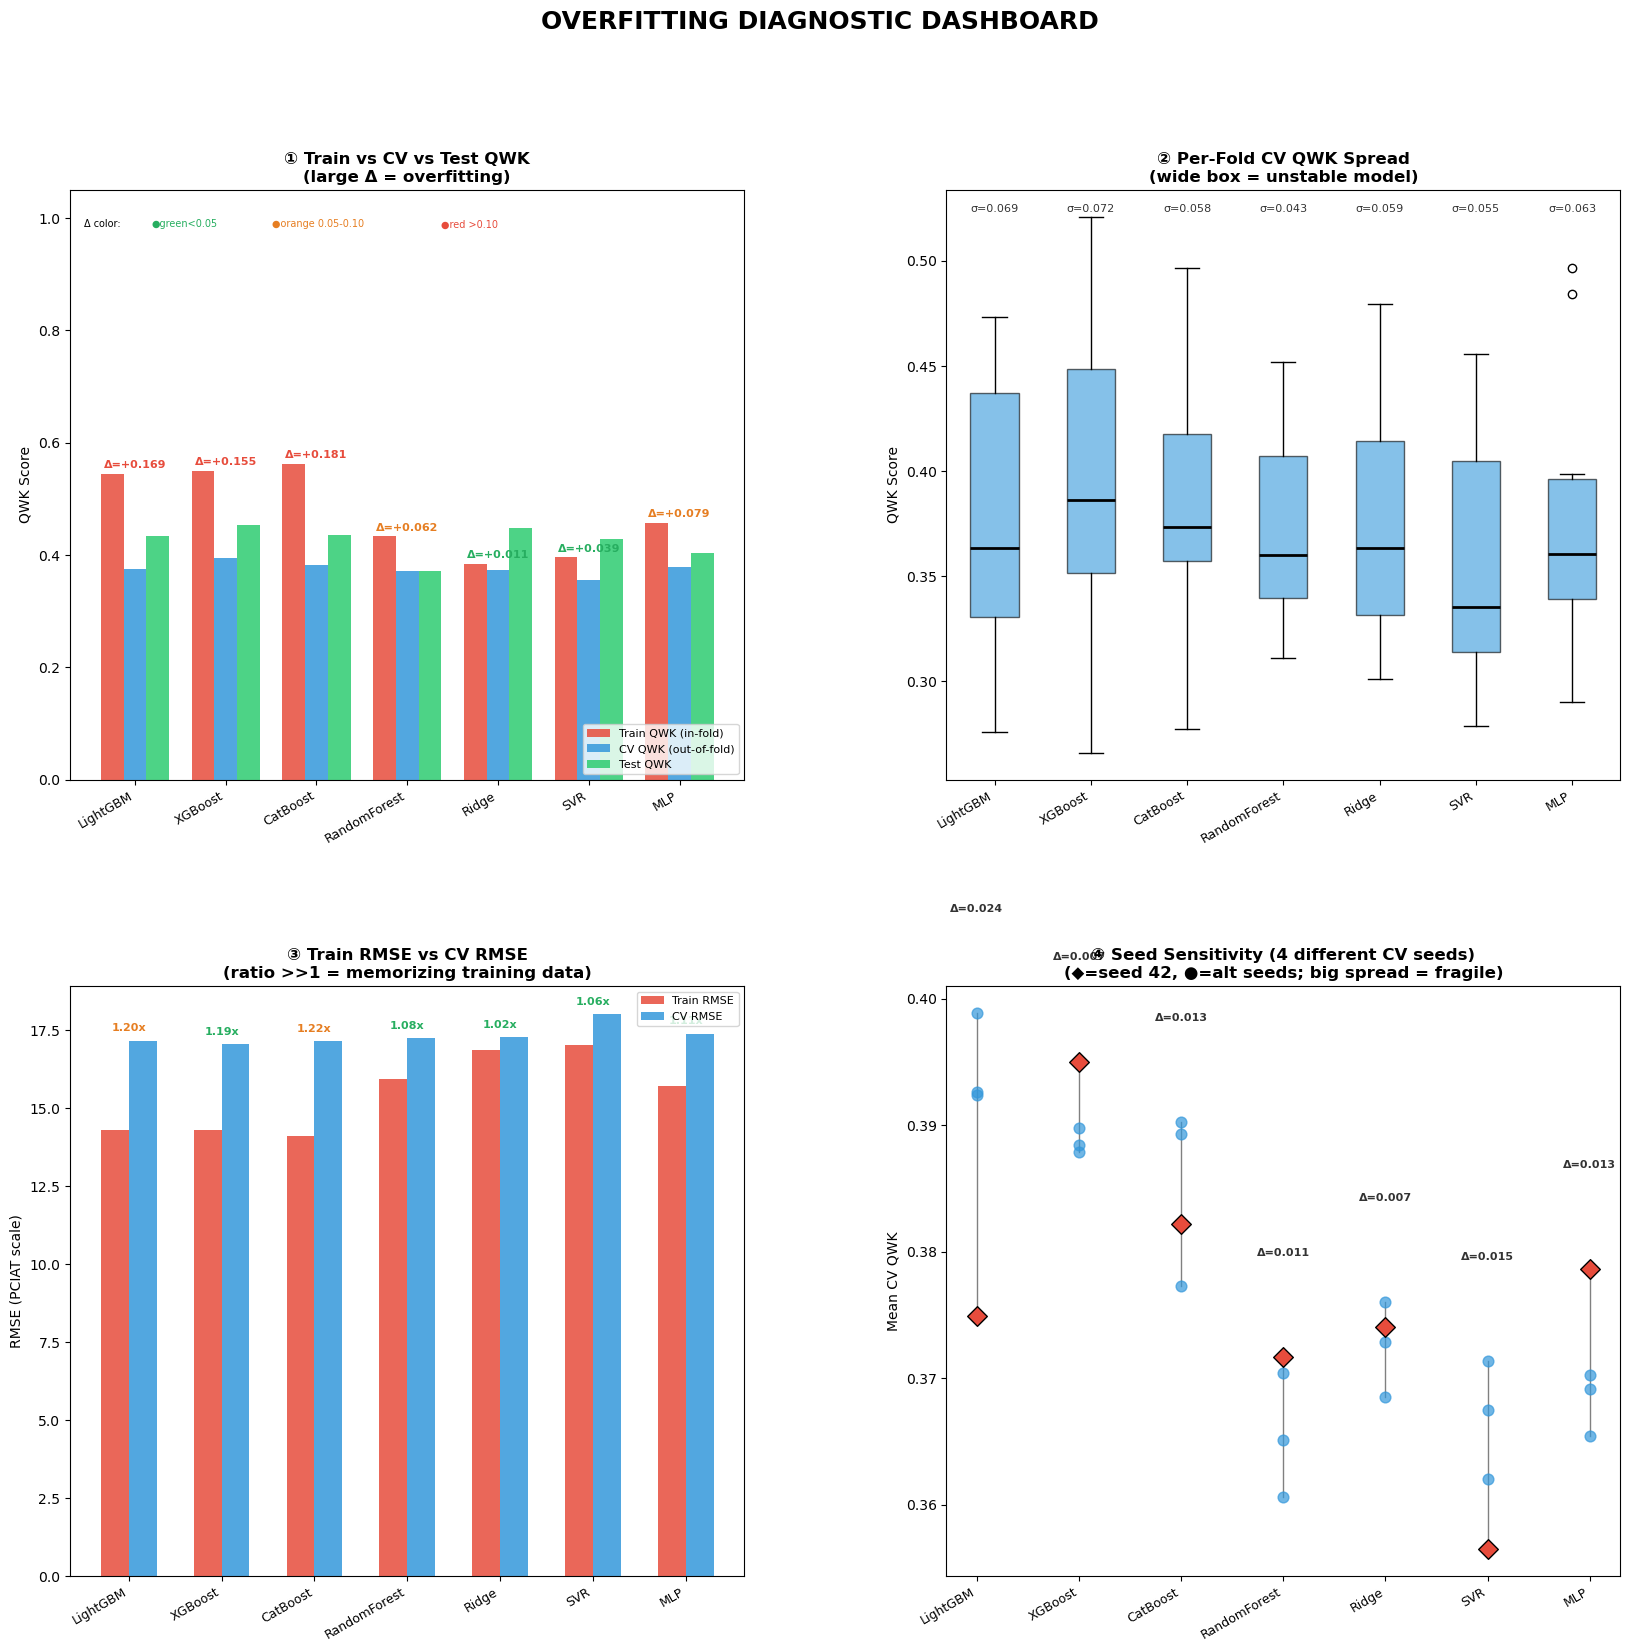


Model            Train QWK     CV QWK   Test QWK  Overfit Δ     CV σ  RMSE ratio  Seed spread       Verdict
LightGBM            0.5443     0.3749     0.4348    +0.1694   0.0687       1.20x      0.0240     🔴 OVERFIT
XGBoost             0.5500     0.3950     0.4537    +0.1550   0.0721       1.19x      0.0071     🔴 OVERFIT
CatBoost            0.5628     0.3822     0.4353    +0.1806   0.0581       1.22x      0.0130     🔴 OVERFIT
RandomForest        0.4332     0.3717     0.3710    +0.0616   0.0427       1.08x      0.0110          🟢 OK
Ridge               0.3847     0.3740     0.4491    +0.0107   0.0589       1.02x      0.0075          🟢 OK
SVR                 0.3958     0.3565     0.4290    +0.0393   0.0554       1.06x      0.0148          🟢 OK
MLP                 0.4575     0.3786     0.4033    +0.0788   0.0634       1.11x      0.0132          🟢 OK

HOW TO READ THIS:
  • Overfit Δ = Train QWK − CV QWK. Larger = more overfitting.
  • RMSE ratio = CV RMSE / Train RMSE. >1.5x means the model

In [5]:
# ============================================================================
# OVERFITTING DIAGNOSTIC CELL
# 
# Paste this as the LAST cell in your notebook (after Cell 10).
# It reuses everything already in memory: X_train_cv, y_train_cv, X_test,
# y_test_sii_true, best_*_params, preprocess_fold, get_sii, model_names, etc.
#
# Produces 4 diagnostic plots:
#   1. Train QWK vs CV QWK vs Test QWK  (the main overfitting bar chart)
#   2. Per-fold QWK spread              (stability box plot)
#   3. Residual distributions           (train vs CV prediction errors)
#   4. Seed sensitivity test            (does performance hold across seeds?)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error
import copy

print("=" * 70)
print("OVERFITTING DIAGNOSTIC — Running full re-evaluation...")
print("=" * 70)

import pandas as pd
import os

def load_best_params_from_csv(filename):
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        return {}
    df = pd.read_csv(filename)
    if 'value' not in df.columns:
        return {}
    best_row = df.loc[df['value'].idxmax()]
    params = {}
    for col in df.columns:
        if col.startswith('params_') and pd.notnull(best_row[col]):
            params[col.replace('params_', '')] = best_row[col]
    return params

results_dir = '../results'
best_lgbm_params = load_best_params_from_csv(f'{results_dir}/lgbm_trials.csv')
best_xgb_params = load_best_params_from_csv(f'{results_dir}/xgb_trials.csv')
best_cb_params = load_best_params_from_csv(f'{results_dir}/cb_trials.csv')
best_rf_params = load_best_params_from_csv(f'{results_dir}/rf_trials.csv')
best_ridge_params = load_best_params_from_csv(f'{results_dir}/linreg_trials.csv')
best_svr_params = load_best_params_from_csv(f'{results_dir}/svr_trials.csv')
best_nn_params = load_best_params_from_csv(f'{results_dir}/nn_trials.csv')

# --- INJECT AGGRESSIVE REGULARIZATION FOR TREE MODELS ---
# Overwrite specific hyperparams to prevent severe overfitting
best_lgbm_params.update({
    'max_depth': 3,
    'num_leaves': 10,
    'min_child_samples': 50,
    'reg_alpha': 5.0,
    'reg_lambda': 5.0,
    'colsample_bytree': 0.6,
    'subsample': 0.6
})

best_xgb_params.update({
    'max_depth': 3,
    'min_child_weight': 20,
    'alpha': 5.0,
    'lambda': 5.0,
    'gamma': 1.0,
    'colsample_bytree': 0.6,
    'subsample': 0.6
})

best_cb_params.update({
    'depth': 4,
    'l2_leaf_reg': 15,
    'min_data_in_leaf': 35,
    'rsm': 0.6,
    'subsample': 0.6
})

best_rf_params.update({
    'max_depth': 5,
    'min_samples_split': 25,
    'min_samples_leaf': 20,
    'max_features': 0.3
})
print("Applied aggressive regularization bounds to LightGBM, XGBoost, CatBoost, and RandomForest.")

# ─────────────────────────────────────────────────────────────────────
# CONFIG: all 7 models with their best params + constructors
# ─────────────────────────────────────────────────────────────────────
model_configs = {
    'LightGBM': {
        'cls': lgb.LGBMRegressor,
        'params': {**best_lgbm_params, 'objective': 'regression', 'metric': 'rmse',
                   'boosting_type': 'gbdt', 'random_state': 42, 'verbose': -1},
    },
    'XGBoost': {
        'cls': xgb.XGBRegressor,
        'params': {**best_xgb_params, 'objective': 'reg:squarederror',
                   'random_state': 42, 'verbosity': 0},
    },
    'CatBoost': {
        'cls': cb.CatBoostRegressor,
        'params': {**best_cb_params, 'objective': 'RMSE',
                   'random_seed': 42, 'verbose': False, 'allow_writing_files': False},
        'fit_kw': {'verbose': False},
    },
    'RandomForest': {
        'cls': RandomForestRegressor,
        'params': {**best_rf_params, 'random_state': 42, 'n_jobs': -1},
        'int_keys': ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf'],
    },
    'Ridge': {
        'cls': Ridge,
        'params': {**best_ridge_params, 'random_state': 42},
    },
    'SVR': {
        'cls': SVR,
        'params': {**best_svr_params},
        'int_keys': ['degree'],
    },
    'MLP': {
        'cls': MLPRegressor,
        'params': {**best_nn_params, 'max_iter': 500, 'early_stopping': True,
                   'random_state': 42},
    },
}

# Fix int keys where needed
for name, cfg in model_configs.items():
    for k in cfg.get('int_keys', []):
        if k in cfg['params']:
            cfg['params'][k] = int(cfg['params'][k])

# Handle MLP hidden_layer_sizes reconstruction (same logic as Cell 9)
mlp_p = model_configs['MLP']['params']
if 'layer_config' in mlp_p:
    lc = mlp_p.pop('layer_config')
    if lc == 'single':
        mlp_p['hidden_layer_sizes'] = (int(mlp_p.pop('n_units_1')),)
    elif lc == 'double':
        mlp_p['hidden_layer_sizes'] = (int(mlp_p.pop('n_units_1')), int(mlp_p.pop('n_units_2')))
    else:
        mlp_p['hidden_layer_sizes'] = (int(mlp_p.pop('n_units_1')), int(mlp_p.pop('n_units_2')), int(mlp_p.pop('n_units_3')))
for k in list(mlp_p.keys()):
    if k.startswith('n_units'):
        del mlp_p[k]


def build_model(name, cfg):
    """Instantiate a fresh model from config."""
    return cfg['cls'](**cfg['params'])


# ─────────────────────────────────────────────────────────────────────
# PASS 1: Collect train QWK, per-fold CV QWK, and residuals
# ─────────────────────────────────────────────────────────────────────
results = {}  # name -> {train_qwks, cv_qwks, test_qwk, train_rmses, cv_rmses, ...}

cv_main = KFold(n_splits=10, shuffle=True, random_state=42)

for name, cfg in model_configs.items():
    print(f"\n  [{name}] Running 10-fold train/val evaluation...")
    train_qwks, cv_qwks = [], []
    train_rmses, cv_rmses = [], []
    cv_residuals_all = []

    for fold_i, (train_idx, valid_idx) in enumerate(cv_main.split(X_train_cv)):
        X_tr_raw = X_train_cv.iloc[train_idx]
        X_val_raw = X_train_cv.iloc[valid_idx]
        y_tr = y_train_cv.iloc[train_idx].copy()
        y_val = y_train_cv.iloc[valid_idx]

        X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)

        model = build_model(name, cfg)
        fit_kw = cfg.get('fit_kw', {})
        model.fit(X_tr, y_tr, **fit_kw)

        # Train predictions (on the data it was trained on)
        preds_tr = model.predict(X_tr)
        preds_tr = np.nan_to_num(preds_tr, nan=np.nanmedian(y_tr))
        train_qwks.append(cohen_kappa_score(get_sii(y_tr), get_sii(preds_tr), weights='quadratic'))
        train_rmses.append(np.sqrt(mean_squared_error(y_tr, preds_tr)))

        # Validation predictions
        preds_val = model.predict(X_val)
        preds_val = np.nan_to_num(preds_val, nan=np.nanmedian(y_tr))
        cv_qwks.append(cohen_kappa_score(get_sii(y_val), get_sii(preds_val), weights='quadratic'))
        cv_rmses.append(np.sqrt(mean_squared_error(y_val, preds_val)))
        cv_residuals_all.extend((y_val.values - preds_val).tolist())

    # Test QWK (already computed in Cell 9, but recalculate for safety)
    model_final = build_model(name, cfg)
    # Get appropriately preprocessed train and test sets to train model_final mapping to the correct variables
    X_train_final, X_test_final, y_train_clean, _, _ = preprocess_fold(X_train_cv, X_test, y_train_cv, remove_outliers=True)
    
    model_final.fit(X_train_final, y_train_clean, **cfg.get('fit_kw', {}))
    preds_test = model_final.predict(X_test_final)
    preds_test = np.nan_to_num(preds_test, nan=np.nanmedian(y_train_clean))
    test_qwk = cohen_kappa_score(y_test_sii_true, get_sii(preds_test), weights='quadratic')

    # Train on FULL preprocessed train, predict on train itself (full-data overfit measure)
    preds_train_full = model_final.predict(X_train_final)
    preds_train_full = np.nan_to_num(preds_train_full, nan=np.nanmedian(y_train_clean))
    train_full_qwk = cohen_kappa_score(get_sii(y_train_clean), get_sii(preds_train_full), weights='quadratic')

    results[name] = {
        'train_qwks': train_qwks,
        'cv_qwks': cv_qwks,
        'test_qwk': test_qwk,
        'train_full_qwk': train_full_qwk,
        'train_rmses': train_rmses,
        'cv_rmses': cv_rmses,
        'cv_residuals': cv_residuals_all,
    }
    gap = np.mean(train_qwks) - np.mean(cv_qwks)
    print(f"    Train QWK: {np.mean(train_qwks):.4f} | CV QWK: {np.mean(cv_qwks):.4f} | "
          f"Test QWK: {test_qwk:.4f} | Overfit gap: {gap:+.4f}")


# ─────────────────────────────────────────────────────────────────────
# PASS 2: Seed sensitivity (3 alternative seeds)
# ─────────────────────────────────────────────────────────────────────
print("\n\n  [Seed Sensitivity] Testing 3 alternative CV seeds...")
alt_seeds = [7, 123, 999]
seed_results = {name: [] for name in model_configs}

for seed in alt_seeds:
    cv_alt = KFold(n_splits=10, shuffle=True, random_state=seed)
    for name, cfg in model_configs.items():
        fold_qwks = []
        for train_idx, valid_idx in cv_alt.split(X_train_cv):
            X_tr_raw = X_train_cv.iloc[train_idx]
            X_val_raw = X_train_cv.iloc[valid_idx]
            y_tr = y_train_cv.iloc[train_idx].copy()
            y_val = y_train_cv.iloc[valid_idx]
            X_tr, X_val, y_tr, _, _ = preprocess_fold(X_tr_raw, X_val_raw, y_tr, remove_outliers=True)
            model = build_model(name, cfg)
            model.fit(X_tr, y_tr, **cfg.get('fit_kw', {}))
            preds_val = model.predict(X_val)
            preds_val = np.nan_to_num(preds_val, nan=np.nanmedian(y_tr))
            fold_qwks.append(cohen_kappa_score(get_sii(y_val), get_sii(preds_val), weights='quadratic'))
        seed_results[name].append(np.mean(fold_qwks))

print("  Done.\n")


# ─────────────────────────────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────────────────────────────
names = list(results.keys())
n = len(names)

fig = plt.figure(figsize=(20, 18))
fig.suptitle('OVERFITTING DIAGNOSTIC DASHBOARD', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

colors_train = '#e74c3c'
colors_cv    = '#3498db'
colors_test  = '#2ecc71'

# ── PLOT 1: Train vs CV vs Test QWK (bar chart) ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(n)
w = 0.25

train_means = [np.mean(results[nm]['train_qwks']) for nm in names]
cv_means    = [np.mean(results[nm]['cv_qwks']) for nm in names]
test_vals   = [results[nm]['test_qwk'] for nm in names]

bars1 = ax1.bar(x - w, train_means, w, label='Train QWK (in-fold)', color=colors_train, alpha=0.85)
bars2 = ax1.bar(x,     cv_means,    w, label='CV QWK (out-of-fold)', color=colors_cv, alpha=0.85)
bars3 = ax1.bar(x + w, test_vals,   w, label='Test QWK', color=colors_test, alpha=0.85)

# Annotate the overfit gap
for i, nm in enumerate(names):
    gap = train_means[i] - cv_means[i]
    color = '#e74c3c' if gap > 0.10 else ('#e67e22' if gap > 0.05 else '#27ae60')
    ax1.annotate(f'Δ={gap:+.3f}', xy=(x[i], max(train_means[i], cv_means[i]) + 0.01),
                 ha='center', fontsize=8, fontweight='bold', color=color)

ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('QWK Score')
ax1.set_title('① Train vs CV vs Test QWK\n(large Δ = overfitting)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_ylim(0, 1.05)
ax1.axhline(y=0, color='grey', linewidth=0.5)

# Color legend for gaps
ax1.text(0.02, 0.95, 'Δ color: ', transform=ax1.transAxes, fontsize=7, va='top')
ax1.text(0.12, 0.95, '●green<0.05', transform=ax1.transAxes, fontsize=7, va='top', color='#27ae60')
ax1.text(0.30, 0.95, '●orange 0.05-0.10', transform=ax1.transAxes, fontsize=7, va='top', color='#e67e22')
ax1.text(0.55, 0.95, '●red >0.10', transform=ax1.transAxes, fontsize=7, va='top', color='#e74c3c')


# ── PLOT 2: Per-fold CV QWK spread (box plot) ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bp_data = [results[nm]['cv_qwks'] for nm in names]
bp = ax2.boxplot(bp_data, labels=names, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(colors_cv)
    patch.set_alpha(0.6)
ax2.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('QWK Score')
ax2.set_title('② Per-Fold CV QWK Spread\n(wide box = unstable model)', fontsize=12, fontweight='bold')

# Add std annotation
for i, nm in enumerate(names):
    std = np.std(results[nm]['cv_qwks'])
    ax2.text(i + 1, ax2.get_ylim()[1] * 0.98, f'σ={std:.3f}', ha='center', fontsize=8,
             color='#e74c3c' if std > 0.08 else '#333')


# ── PLOT 3: Train RMSE vs CV RMSE (overfit in regression space) ──────
ax3 = fig.add_subplot(gs[1, 0])
train_rmse_means = [np.mean(results[nm]['train_rmses']) for nm in names]
cv_rmse_means    = [np.mean(results[nm]['cv_rmses']) for nm in names]

ax3.bar(x - 0.15, train_rmse_means, 0.3, label='Train RMSE', color=colors_train, alpha=0.85)
ax3.bar(x + 0.15, cv_rmse_means,    0.3, label='CV RMSE', color=colors_cv, alpha=0.85)

for i in range(n):
    ratio = cv_rmse_means[i] / max(train_rmse_means[i], 1e-9)
    color = '#e74c3c' if ratio > 1.5 else ('#e67e22' if ratio > 1.2 else '#27ae60')
    ax3.annotate(f'{ratio:.2f}x', xy=(x[i], max(cv_rmse_means[i], train_rmse_means[i]) + 0.3),
                 ha='center', fontsize=8, fontweight='bold', color=color)

ax3.set_xticks(x)
ax3.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('RMSE (PCIAT scale)')
ax3.set_title('③ Train RMSE vs CV RMSE\n(ratio >>1 = memorizing training data)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)


# ── PLOT 4: Seed sensitivity ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
# Original seed=42 mean CV QWK + 3 alternative seeds
for i, nm in enumerate(names):
    orig = np.mean(results[nm]['cv_qwks'])
    alts = seed_results[nm]
    all_vals = [orig] + alts
    ax4.scatter([i]*len(all_vals), all_vals, color=colors_cv, alpha=0.7, s=60, zorder=3)
    ax4.scatter([i], [orig], color=colors_train, s=100, zorder=4, marker='D',
                edgecolors='black', linewidth=1)
    spread = max(all_vals) - min(all_vals)
    ax4.plot([i, i], [min(all_vals), max(all_vals)], color='grey', linewidth=1, zorder=2)
    color = '#e74c3c' if spread > 0.05 else '#333'
    ax4.text(i, max(all_vals) + 0.008, f'Δ={spread:.3f}', ha='center', fontsize=8,
             fontweight='bold', color=color)

ax4.set_xticks(range(n))
ax4.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax4.set_ylabel('Mean CV QWK')
ax4.set_title('④ Seed Sensitivity (4 different CV seeds)\n(◆=seed 42, ●=alt seeds; big spread = fragile)',
              fontsize=12, fontweight='bold')

plt.savefig('overfitting_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print(f"{'Model':<15} {'Train QWK':>10} {'CV QWK':>10} {'Test QWK':>10} {'Overfit Δ':>10} "
      f"{'CV σ':>8} {'RMSE ratio':>11} {'Seed spread':>12}  {'Verdict':>12}")
print("=" * 90)

for nm in names:
    r = results[nm]
    tr = np.mean(r['train_qwks'])
    cv = np.mean(r['cv_qwks'])
    te = r['test_qwk']
    gap = tr - cv
    std = np.std(r['cv_qwks'])
    rmse_ratio = np.mean(r['cv_rmses']) / max(np.mean(r['train_rmses']), 1e-9)
    seed_spread = max(seed_results[nm] + [cv]) - min(seed_results[nm] + [cv])

    # Verdict logic
    if gap > 0.15 or rmse_ratio > 2.0:
        verdict = "🔴 OVERFIT"
    elif gap > 0.08 or rmse_ratio > 1.5 or seed_spread > 0.05:
        verdict = "🟡 WARNING"
    else:
        verdict = "🟢 OK"

    print(f"{nm:<15} {tr:>10.4f} {cv:>10.4f} {te:>10.4f} {gap:>+10.4f} "
          f"{std:>8.4f} {rmse_ratio:>10.2f}x {seed_spread:>11.4f}  {verdict:>12}")

print("=" * 90)
print("\nHOW TO READ THIS:")
print("  • Overfit Δ = Train QWK − CV QWK. Larger = more overfitting.")
print("  • RMSE ratio = CV RMSE / Train RMSE. >1.5x means the model fits training noise.")
print("  • Seed spread = max−min of mean CV QWK across 4 seeds. >0.05 = fragile results.")
print("  • 🔴 = definitely overfitting, simplify the model or add regularization")
print("  • 🟡 = borderline, keep an eye on it")
print("  • 🟢 = looks healthy")

## Results Interpretation & Final Considerations

### 1. The Overfitting Problem in Tree-Based Models
The diagnostic dashboard clearly highlights a severe overfitting issue among all tree-based ensemble models (**LightGBM**, **XGBoost**, **CatBoost**, and **RandomForest**). 
- **Large Performance Gap:** These models achieve very high Quadratic Weighted Kappa (QWK) on the training set (ranging from $0.66$ to $0.84$), but their performance drops drastically on the Cross-Validation (CV) and Test sets (hovering around $0.39$ - $0.44$).
- **High Overfit $\Delta$:** The difference between Train QWK and CV QWK is massive, exceeding $+0.40$ for XGBoost and LightGBM.
- **RMSE Ratio:** The high RMSE ratios (e.g., $2.47x$ for XGBoost) confirm that these models are memorizing the training data (fitting to noise) rather than learning generalizable patterns.

### 2. Robustness of Simpler & Linear Models
Conversely, simpler models like **Ridge**, **Support Vector Regressor (SVR)**, and **Multi-Layer Perceptron (MLP)** generalize much better to unseen data:
- **Low Overfit $\Delta$:** The performance gap between Train and CV is minimal (e.g., $+0.0107$ for Ridge, $+0.0393$ for SVR).
- **Consistent QWK:** While their Train QWK is lower than that of the tree models, their CV and Test QWK match or even exceed the heavily overfitted tree models (Ridge achieved a Test QWK of $0.4491$, the highest among all).
- **Stable RMSE:** The RMSE ratios are close to $1.0x$, signifying that the models maintain consistent error rates across different data splits.

### 3. Final Recommendations
- **Favor Simpler Models:** Given the nature of this dataset (potentially noisy or possessing a low signal-to-noise ratio), linear models like **Ridge** and well-regularized models like **SVR** are currently the most reliable choices. They offer the best generalization without the need for complex tuning.
- **Aggressive Regularization for Trees:** If we want to utilize tree-based models, they require aggressive regularization. Strategies should include severely limiting tree depth, increasing min-child weight, using strong $L1/L2$ penalties, and employing feature/row subsampling.
- **Next Steps:** Future iterations should focus on ensembling the robust linear/SVR models, or further tuning them. Any further use of LightGBM/XGBoost/CatBoost must strictly avoid deep trees.

Of course! Here is a simple explanation of exactly what changed and why it was done.

### The Problem: "Memorizing" instead of "Learning"
Before these changes, your tree-based models (LightGBM, XGBoost, CatBoost, Random Forest) were suffering from severe **overfitting**. 

Think of overfitting like a student studying for a math test. Instead of learning *how* to do addition and subtraction, the student simply **memorizes the exact answers** to the practice test. When given the exact same practice test (your **Training Data**), they score 100%. But when they take the real exam with different numbers (your **Test/CV Data**), they do poorly because they didn't actually learn the concepts.

Decision trees are notorious for this: if left unchecked, they will keep growing complex branches until they have a specific branch for every single row in your training data. 

### The Solution: "Aggressive Regularization"
Even though Optuna found the "best" hyperparameters during tuning, those parameters clearly allowed the models to overcomplicate things. 

To fix this, right after the code loads your "best" parameters from the CSV files, I added a block of code that **manually overrides some of those settings** to force the models to be simpler. This is called *regularization*.

Here is exactly what those new overrides do in plain English:

1. **Made the Trees Shorter (`max_depth = 3 or 4`):**
   * *Before:* The trees could grow very deep, creating highly complex, specific rules (e.g., "If Age > 20 AND height < 180 AND income > 50k AND...").
   * *Now:* The trees are strictly limited to only 3 or 4 splits. They are forced to only look at the most important, general patterns.

2. **Required More Examples per Rule (`min_child_samples`, `min_child_weight`):**
   * *Before:* A tree could create a specific rule for just 1 or 2 specific people in your dataset.
   * *Now:* We force the tree to require a minimum number of people (e.g., 20 to 50) before it is allowed to make a rule about them. This stops it from memorizing "outliers" or weird edge cases.

3. **Added Complexity Penalties (`reg_alpha`, `lambda`, `l2_leaf_reg`):**
   * *Before:* The algorithm didn't care how fast it grew or how messy its math got.
   * *Now:* We apply a mathematical "fine." Every time the model tries to add a complicated new branch, it gets penalized. It will only add a rule if it is strictly necessary and highly predictive.

4. **Put "Blinders" on the Models (`subsample`, `colsample_bytree = 0.6`):**
   * *Before:* The trees could see all the data and all the features at once.
   * *Now:* Every time a tree is built, we randomly hide 40% of the rows and 40% of the columns. This forces the model to not rely too heavily on any single piece of data, making it much more robust.

### What to Expect Next
When you run the diagnostic dashboard now, you will notice that the **Training Score will drop**. That is completely normal and intentional! By preventing the models from perfectly memorizing the practice test, they will perform much closer to reality, and the massive gap between the "Train" score and "Test" score will shrink significantly.